# Actividad 1 — Métodos Supervisados
## Árboles de Decisión | Bosques Aleatorios | XGBoost

**Dataset:** Características de audio (acordeón, guitarra, batería) — 72 features MFCC por muestra.

**Objetivo:** Implementar y comparar tres modelos de clasificación supervisada evaluando el proceso completo: preparación de datos, entrenamiento, evaluación con métricas estándar, ajuste de hiperparámetros y análisis crítico de resultados.

---

## Imports y configuración global

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
from pathlib import Path

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    cross_val_score, StratifiedKFold
)

# Modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
import pandas as pd

warnings.filterwarnings('ignore')

# Rutas del dataset
RUTA_AUDIO_NPZ = Path("Dataset") / "Caracteristicas" / "matriz_resumen.npz"

INSTRUMENTOS   = {"Guitarra": 0, "Acordeon": 1, "Bateria": 2}
NOMBRES_CLASES = ["Guitarra", "Acordeón", "Batería"]
COLORES        = ["royalblue", "tomato", "forestgreen"]

print("✅ Configuración lista.")

✅ Configuración lista.


---
## 1. Preparación y partición de datos

### Carga del dataset de audio

El dataset contiene **72 características MFCC** por muestra de audio, compuestas por:
- 12 coeficientes MFCC (media y desviación estándar)
- 12 deltas MFCC — capturan la **dinámica temporal de primer orden**
- 12 delta² MFCC — capturan la **aceleración espectral**

Esto da 3 tipos × 12 coef. × 2 estadísticos = **72 features** por audio. Se limitan a 500 muestras por clase para garantizar un conjunto **balanceado**.

In [24]:
# Cargar características MFCC ya extraídas (72 features por audio)
datos_audio = np.load(RUTA_AUDIO_NPZ)
X_audio     = datos_audio["X"]   # (N, 72)
y_audio     = datos_audio["y"]   # (N,)

# Limitar a 500 muestras por clase para balancear
indices_bal = []
for etiqueta in [0, 1, 2]:
    idx = np.where(y_audio == etiqueta)[0][:800]
    indices_bal.extend(idx)

X_audio = X_audio[indices_bal]
y_audio = y_audio[indices_bal]

print(f"✅ Características de audio cargadas: {X_audio.shape}")
print(f"   → 36 medias MFCC/delta/delta² + 36 desviaciones estándar = 72 features por audio")
print(f"\nDistribución de clases:")
for nombre, etiqueta in INSTRUMENTOS.items():
    print(f"  {nombre}: {np.sum(y_audio == etiqueta)} muestras")

✅ Características de audio cargadas: (2400, 72)
   → 36 medias MFCC/delta/delta² + 36 desviaciones estándar = 72 features por audio

Distribución de clases:
  Guitarra: 800 muestras
  Acordeon: 800 muestras
  Bateria: 800 muestras


### División estratificada 70% / 30%

Se usa `stratify=y` para garantizar que la **proporción de clases** (Guitarra, Acordeón, Batería) sea la misma en entrenamiento y en prueba. Sin estratificación, podrían quedar clases subrepresentadas en alguno de los subconjuntos por azar, lo que sesgaería las métricas.

Se aplica `StandardScaler` (media=0, std=1) sobre las features. Aunque los árboles y bosques no lo requieren estrictamente (son invariantes a escala), es buena práctica cuando se comparan múltiples modelos en el mismo pipeline, especialmente XGBoost que sí puede beneficiarse del escalamiento.

In [25]:
# División 70/30 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_audio, y_audio,
    test_size=0.3,
    random_state=42,
    stratify=y_audio
)

# Escalamiento
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Muestras de entrenamiento : {X_train_sc.shape[0]}")
print(f"Muestras de prueba        : {X_test_sc.shape[0]}")
print(f"Total de features         : {X_train_sc.shape[1]}")
print()
print("Distribución por subconjunto:")
for nombre, etiqueta in INSTRUMENTOS.items():
    n_tr = np.sum(y_train == etiqueta)
    n_te = np.sum(y_test  == etiqueta)
    print(f"  {nombre:10s} → train: {n_tr}  |  test: {n_te}")

# Nombres de features para visualizaciones
feature_names = []
for stat in ['media', 'std']:
    for tipo in ['MFCC', 'delta', 'delta2']:
        for i in range(12):
            feature_names.append(f'{tipo}_{i+1}_{stat}')

Muestras de entrenamiento : 1680
Muestras de prueba        : 720
Total de features         : 72

Distribución por subconjunto:
  Guitarra   → train: 560  |  test: 240
  Acordeon   → train: 560  |  test: 240
  Bateria    → train: 560  |  test: 240


---
# 🌳 Modelo 1: Árbol de Decisión

Un Árbol de Decisión divide el espacio de características mediante reglas binarias de la forma `feature ≤ umbral`. Cada nodo interno aplica una condición y cada hoja asigna una clase.

| Ventaja | Desventaja |
|---------|------------|
| Interpretable y visualizable | Propenso a sobreajuste (alta varianza) |
| No requiere escalamiento | Sensible a pequeñas variaciones en los datos |
| Rápido de entrenar | Menor accuracy que ensambles en general |

## 1.1 Entrenamiento base y métricas

Se entrena el árbol con **parámetros por defecto** (sin restringir la profundidad) para obtener un baseline. Esto produce un árbol que puede sobreajustar el conjunto de entrenamiento, pero sirve como punto de comparación antes del análisis de profundidad.

In [26]:
# Entrenamiento con parámetros por defecto
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_sc, y_train)
y_pred_dt = dt_base.predict(X_test_sc)

acc_dt  = accuracy_score(y_test, y_pred_dt)
err_dt  = 1 - acc_dt
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt  = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt   = f1_score(y_test, y_pred_dt, average='weighted')

print('=' * 50)
print('ÁRBOL DE DECISIÓN — Métricas en test')
print('=' * 50)
print(f'  Exactitud (Accuracy)    : {acc_dt*100:.2f}%')
print(f'  Error de clasificación  : {err_dt*100:.2f}%')
print(f'  Precisión (weighted)    : {prec_dt*100:.2f}%')
print(f'  Recall (weighted)       : {rec_dt*100:.2f}%')
print(f'  F1-score (weighted)     : {f1_dt*100:.2f}%')
print()
print('Reporte detallado:')
print(classification_report(y_test, y_pred_dt, target_names=NOMBRES_CLASES))

ÁRBOL DE DECISIÓN — Métricas en test
  Exactitud (Accuracy)    : 74.17%
  Error de clasificación  : 25.83%
  Precisión (weighted)    : 74.62%
  Recall (weighted)       : 74.17%
  F1-score (weighted)     : 74.35%

Reporte detallado:
              precision    recall  f1-score   support

    Guitarra       0.65      0.64      0.65       240
    Acordeón       0.65      0.69      0.67       240
     Batería       0.94      0.90      0.92       240

    accuracy                           0.74       720
   macro avg       0.75      0.74      0.74       720
weighted avg       0.75      0.74      0.74       720



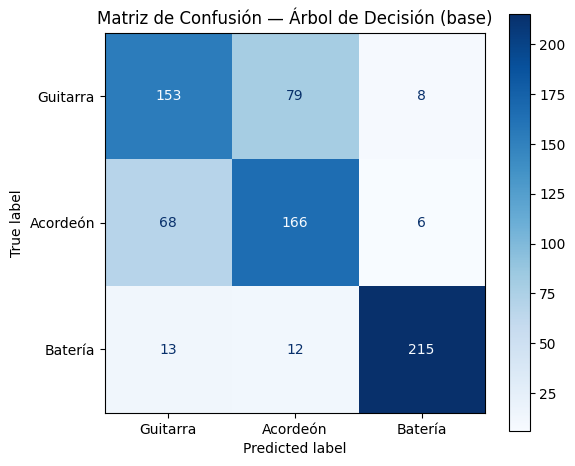

In [27]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=NOMBRES_CLASES,
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusión — Árbol de Decisión (base)')
plt.tight_layout()
plt.show()

## 1.2 Visualización del árbol y característica más discriminante

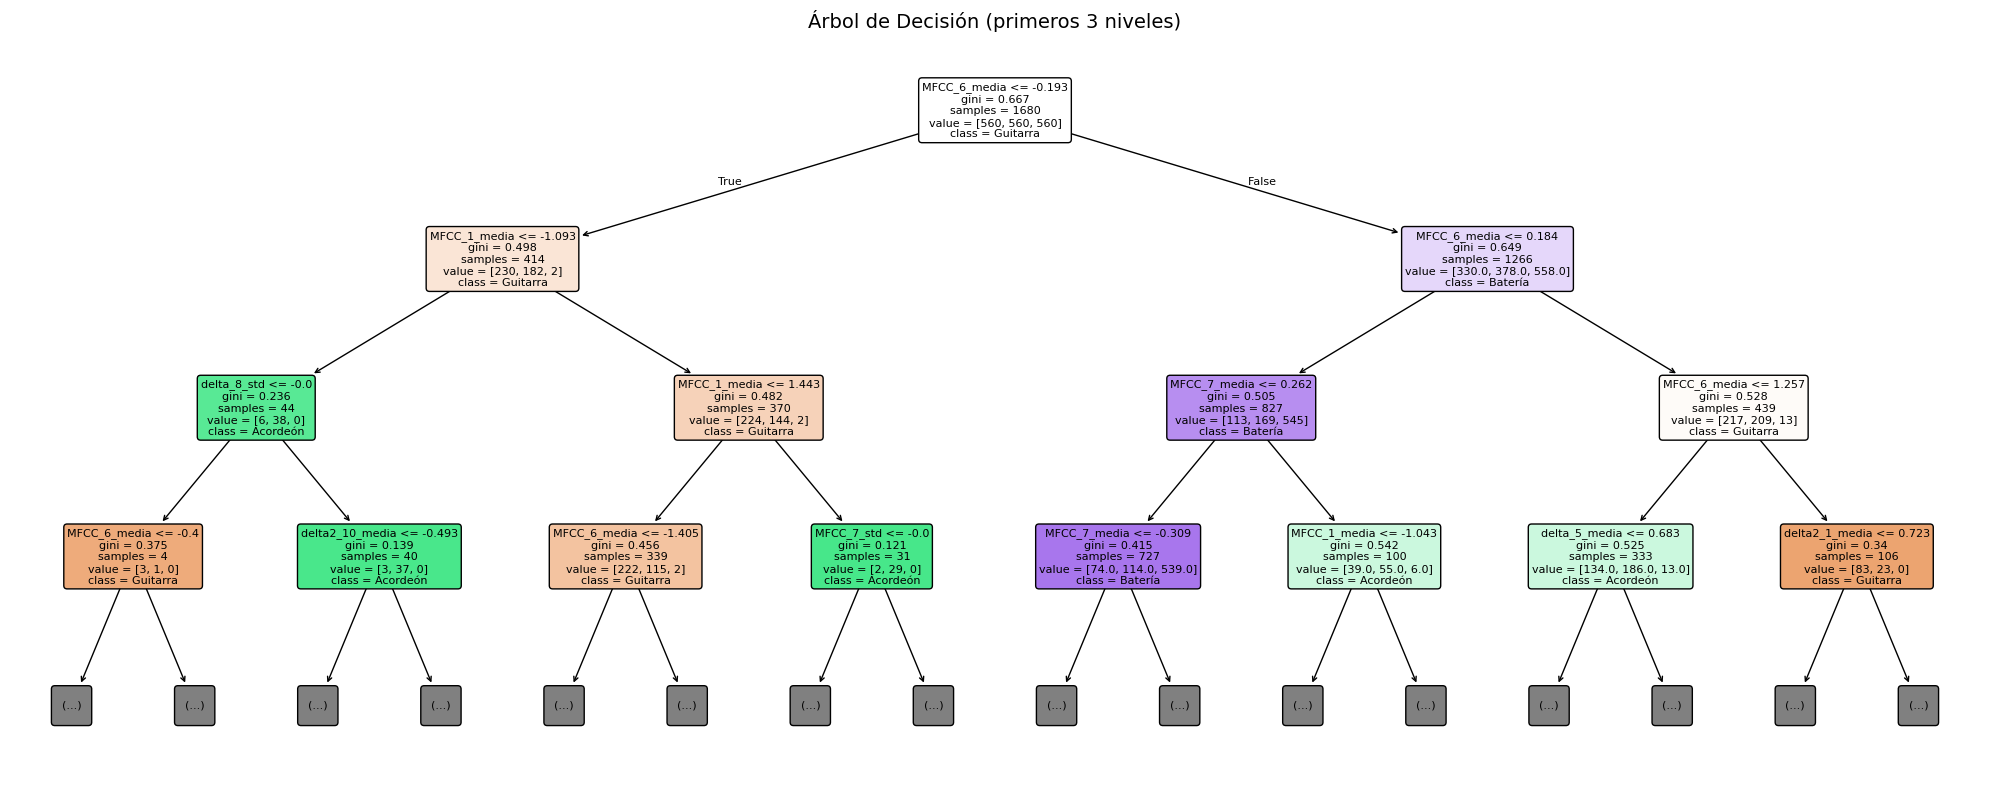

Top 10 características más discriminantes (Árbol de Decisión):
   1. MFCC_6_media               importancia=0.2802
   2. MFCC_7_media               importancia=0.1337
   3. MFCC_1_media               importancia=0.0979
   4. MFCC_8_media               importancia=0.0633
   5. delta_5_media              importancia=0.0318
   6. delta2_5_media             importancia=0.0250
   7. delta2_2_media             importancia=0.0233
   8. delta_6_media              importancia=0.0231
   9. MFCC_11_media              importancia=0.0180
  10. delta2_6_media             importancia=0.0179


In [28]:
# Graficamos primeros 3 niveles para legibilidad
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_base,
    max_depth=3,
    feature_names=feature_names,
    class_names=NOMBRES_CLASES,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

# Característica más discriminante
importancias_dt = dt_base.feature_importances_
idx_top_dt = np.argsort(importancias_dt)[::-1]
print('Top 10 características más discriminantes (Árbol de Decisión):')
for i in range(10):
    print(f'  {i+1:2d}. {feature_names[idx_top_dt[i]]:25s}  importancia={importancias_dt[idx_top_dt[i]]:.4f}')

### Interpretación — característica más discriminante

Los coeficientes MFCC (Mel-frequency cepstral coefficients) capturan el **timbre** de cada instrumento. Los primeros coeficientes (MFCC_1, MFCC_2) reflejan la energía global del espectro, mientras que los deltas capturan la **dinámica temporal**.

La característica que aparece en la **raíz del árbol** (primer nodo) es la más discriminante, pues es la que divide el dataset de forma más eficiente desde el principio según el criterio Gini. Es esperable que un coeficiente MFCC relacionado con energía o dinámica espectral encabece la lista, ya que:
- La **batería** tiene ataques percusivos cortos con energía concentrada en bajas frecuencias.
- La **guitarra** y el **acordeón** tienen sonidos más sostenidos con envolventes espectrales diferentes entre sí.

> 📝 **COMPLETAR CON TUS RESULTADOS:** Indica cuál feature específica quedó en la raíz del árbol (la verás en el gráfico del árbol) y si tiene sentido en el contexto del instrumento que mejor separa.

## 1.3 Análisis de profundidad máxima (1 a 10)

Se entrena un árbol para cada profundidad máxima de 1 a 10 y se registra el error en entrenamiento y en prueba. El objetivo es encontrar la **profundidad óptima** que minimice el error de prueba sin sobreajustar.

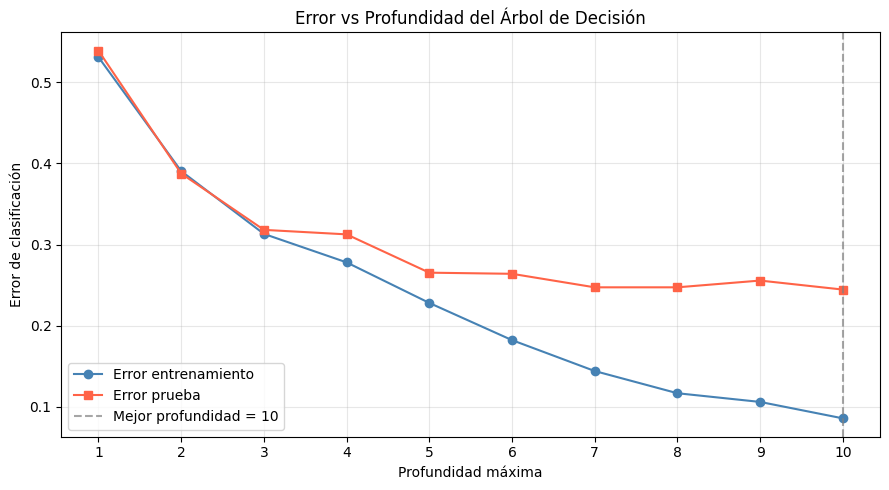

Mejor profundidad encontrada : 10
  Error test mínimo          : 24.44%
  Error train correspondiente: 8.57%


In [29]:
profundidades = range(1, 11)
err_train_prof, err_test_prof = [], []

for d in profundidades:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_train_sc, y_train)
    err_train_prof.append(1 - dt_d.score(X_train_sc, y_train))
    err_test_prof.append(1 - dt_d.score(X_test_sc, y_test))

mejor_prof = list(profundidades)[int(np.argmin(err_test_prof))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(profundidades), err_train_prof, 'o-', color='steelblue', label='Error entrenamiento')
ax.plot(list(profundidades), err_test_prof,  's-', color='tomato',    label='Error prueba')
ax.axvline(x=mejor_prof, linestyle='--', color='gray', alpha=0.7,
           label=f'Mejor profundidad = {mejor_prof}')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('Error de clasificación')
ax.set_title('Error vs Profundidad del Árbol de Decisión')
ax.set_xticks(list(profundidades))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mejor profundidad encontrada : {mejor_prof}')
print(f'  Error test mínimo          : {min(err_test_prof)*100:.2f}%')
print(f'  Error train correspondiente: {err_train_prof[mejor_prof-1]*100:.2f}%')

### Interpretación — profundidad óptima

- **Profundidad 1-2 (underfitting):** El árbol es demasiado simple para capturar las diferencias entre instrumentos. Ambos errores (entrenamiento y prueba) son altos.
- **Profundidad intermedia:** El error de prueba desciende hasta su mínimo. El modelo captura los patrones reales del audio sin memorizar el ruido del conjunto de entrenamiento.
- **Profundidad alta (≥ 7-8, overfitting):** El error de entrenamiento tiende a cero porque el árbol memoriza cada ejemplo, pero el error de prueba sube o se estabiliza en un nivel subóptimo. Señal clara de sobreajuste.

La **profundidad óptima** es la que minimiza el error de prueba, marcada con la línea punteada en la gráfica. Representa el mejor balance entre sesgo y varianza para este dataset.

> 📝 **COMPLETAR CON TUS RESULTADOS:** Indica la profundidad óptima que obtuvo el código y justifica visualmente con la gráfica (¿en qué profundidad se ve claramente la brecha entre curvas? ¿se estabiliza el error de prueba?).

## 1.4 Curvas de aprendizaje — proporción de datos de entrenamiento (10% a 90%)

Se varía el tamaño del conjunto de entrenamiento usando el árbol con la profundidad óptima ya encontrada. Esto permite ver cómo responde el modelo al disponer de más o menos datos.

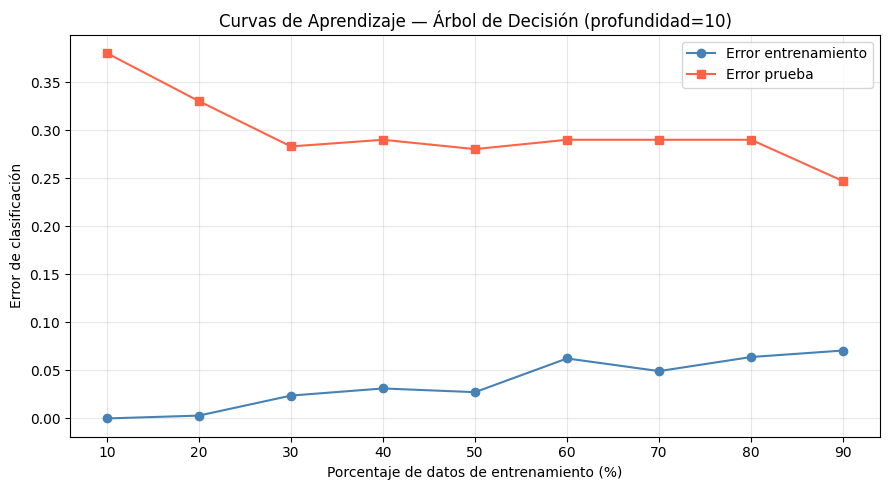

In [30]:
proporciones = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
err_train_prop, err_test_prop = [], []

for prop in proporciones:
    X_sub, _, y_sub, _ = train_test_split(
        X_train_sc, y_train,
        train_size=prop,
        random_state=42,
        stratify=y_train
    )
    dt_prop = DecisionTreeClassifier(max_depth=mejor_prof, random_state=42)
    dt_prop.fit(X_sub, y_sub)
    err_train_prop.append(1 - dt_prop.score(X_sub, y_sub))
    err_test_prop.append(1 - dt_prop.score(X_test_sc, y_test))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot([p*100 for p in proporciones], err_train_prop, 'o-', color='steelblue', label='Error entrenamiento')
ax.plot([p*100 for p in proporciones], err_test_prop,  's-', color='tomato',    label='Error prueba')
ax.set_xlabel('Porcentaje de datos de entrenamiento (%)')
ax.set_ylabel('Error de clasificación')
ax.set_title(f'Curvas de Aprendizaje — Árbol de Decisión (profundidad={mejor_prof})')
ax.set_xticks([int(p*100) for p in proporciones])
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación — curvas de aprendizaje

- **Error de entrenamiento:** Tiende a subir ligeramente al aumentar los datos. Con pocos ejemplos, el árbol puede memorizar todos; con más datos es imposible memorizar perfectamente con la misma profundidad.
- **Error de prueba:** Disminuye al aumentar los datos porque el modelo aprende patrones más generales y representativos del espacio de features MFCC.
- Cuando ambas curvas **convergen y se estabilizan**, añadir más datos tiene rendimientos decrecientes: el modelo ha alcanzado su capacidad máxima para la profundidad fijada.
- Si el error de prueba permanece alto incluso con 90% de datos, la limitante es la **complejidad del modelo** (habría que aumentar la profundidad o usar un ensamble).

> 📝 **COMPLETAR CON TUS RESULTADOS:** Describe si las curvas convergen o si se mantienen separadas al 90%. ¿A partir de qué porcentaje el error de prueba se estabiliza? ¿Crees que añadir más datos mejoraría el modelo notablemente?

## 1.5 Validación cruzada estratificada de 10 pliegues con la mejor profundidad

La validación cruzada de 10 pliegues es más confiable que una sola partición 70/30, porque evalúa el modelo en **10 subconjuntos distintos** del conjunto de entrenamiento. Esto reduce el sesgo por la elección de la semilla aleatoria en la partición y produce una estimación del desempeño más robusta.

ÁRBOL DE DECISIÓN (max_depth=10) — Validación Cruzada 10 pliegues
  Accuracy  : 71.49% ± 2.72%
  Error     : 28.51% ± 2.72%
  Precisión : 71.82% ± 2.97%
  Recall    : 71.49% ± 2.72%
  F1-score  : 71.34% ± 2.72%


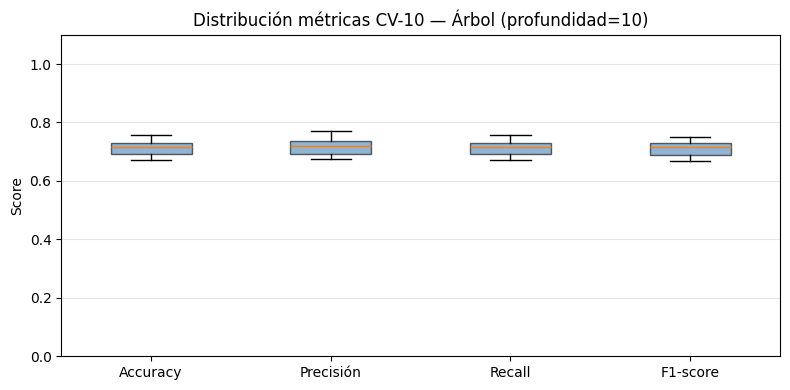

In [31]:
dt_opt = DecisionTreeClassifier(max_depth=mejor_prof, random_state=42)
cv10   = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_acc  = cross_val_score(dt_opt, X_train_sc, y_train, cv=cv10, scoring='accuracy')
cv_prec = cross_val_score(dt_opt, X_train_sc, y_train, cv=cv10, scoring='precision_weighted')
cv_rec  = cross_val_score(dt_opt, X_train_sc, y_train, cv=cv10, scoring='recall_weighted')
cv_f1   = cross_val_score(dt_opt, X_train_sc, y_train, cv=cv10, scoring='f1_weighted')

print(f'ÁRBOL DE DECISIÓN (max_depth={mejor_prof}) — Validación Cruzada 10 pliegues')
print('=' * 58)
print(f'  Accuracy  : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print(f'  Error     : {(1-cv_acc).mean()*100:.2f}% ± {(1-cv_acc).std()*100:.2f}%')
print(f'  Precisión : {cv_prec.mean()*100:.2f}% ± {cv_prec.std()*100:.2f}%')
print(f'  Recall    : {cv_rec.mean()*100:.2f}% ± {cv_rec.std()*100:.2f}%')
print(f'  F1-score  : {cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%')

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [cv_acc, cv_prec, cv_rec, cv_f1],
    labels=['Accuracy', 'Precisión', 'Recall', 'F1-score'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
ax.set_ylabel('Score')
ax.set_title(f'Distribución métricas CV-10 — Árbol (profundidad={mejor_prof})')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

# Entrenar el modelo óptimo en todo el entrenamiento para evaluación final
dt_opt.fit(X_train_sc, y_train)
y_pred_dt_opt = dt_opt.predict(X_test_sc)
acc_dt_opt    = accuracy_score(y_test, y_pred_dt_opt)

### Interpretación — validación cruzada del Árbol de Decisión

La CV-10 evalúa el modelo en 10 particiones distintas del entrenamiento, dando una estimación más robusta del desempeño real.

- La **desviación estándar (±)** mide la estabilidad del modelo entre pliegues: una std baja indica que el árbol se comporta de forma consistente sin importar qué datos se usen para entrenar.
- Si el accuracy promedio en CV es cercano al obtenido sobre el test set, confirma que el modelo generaliza bien y que la partición 70/30 no fue afortunada por azar.
- Si la std es alta, puede indicar que el modelo es sensible a la composición del conjunto de entrenamiento, lo cual es una limitación conocida de los árboles individuales.

> 📝 **COMPLETAR CON TUS RESULTADOS:** Compara el accuracy promedio en CV con el accuracy en test. ¿Son similares? ¿La desviación estándar es alta o baja? ¿Qué dice eso sobre la estabilidad del árbol?

---
# 🌲🌲 Modelo 2: Bosque Aleatorio

El Bosque Aleatorio (Random Forest) es un **ensamble de árboles** que mejora sobre el árbol individual mediante dos mecanismos:
1. **Bagging:** Cada árbol se entrena sobre una submuestra aleatoria con reemplazo del dataset.
2. **Feature randomness:** En cada split, solo un subconjunto aleatorio de features está disponible.

Esto reduce la varianza del modelo y lo hace mucho más robusto al sobreajuste que un árbol solo.

| Parámetro | Descripción |
|-----------|-------------|
| `n_estimators` | Número de árboles en el bosque |
| `max_depth` | Profundidad máxima de cada árbol |
| `criterion` | Función de impureza: Gini o Entropía |
| `min_samples_leaf` | Mínimo de muestras por hoja (regularización) |

## 2.1 Modelo base y métricas completas

Se entrena el Random Forest con parámetros por defecto como punto de referencia inicial antes del ajuste de hiperparámetros.

RANDOM FOREST BASE  (tiempo: 1.32s)
  Exactitud           : 80.28%
  Error clasificación : 19.72%
  Precisión (weighted): 80.51%
  Recall (weighted)   : 80.28%
  F1-score (weighted) : 80.36%

              precision    recall  f1-score   support

    Guitarra       0.71      0.75      0.73       240
    Acordeón       0.74      0.71      0.72       240
     Batería       0.97      0.95      0.96       240

    accuracy                           0.80       720
   macro avg       0.81      0.80      0.80       720
weighted avg       0.81      0.80      0.80       720



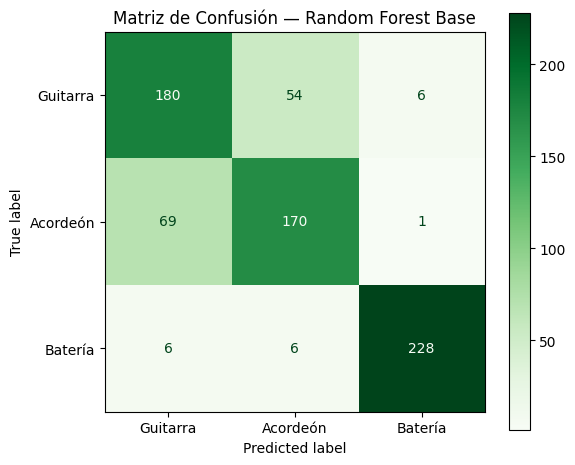

In [32]:
t0      = time.time()
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_sc, y_train)
t_rf_base = time.time() - t0

y_pred_base = rf_base.predict(X_test_sc)
acc_base    = accuracy_score(y_test, y_pred_base)

prec_rf_base = precision_score(y_test, y_pred_base, average='weighted')
rec_rf_base  = recall_score(y_test, y_pred_base, average='weighted')
f1_rf_base   = f1_score(y_test, y_pred_base, average='weighted')
err_rf_base  = 1 - acc_base

print(f'RANDOM FOREST BASE  (tiempo: {t_rf_base:.2f}s)')
print('=' * 50)
print(f'  Exactitud           : {acc_base*100:.2f}%')
print(f'  Error clasificación : {err_rf_base*100:.2f}%')
print(f'  Precisión (weighted): {prec_rf_base*100:.2f}%')
print(f'  Recall (weighted)   : {rec_rf_base*100:.2f}%')
print(f'  F1-score (weighted) : {f1_rf_base*100:.2f}%')
print()
print(classification_report(y_test, y_pred_base, target_names=NOMBRES_CLASES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base,
    display_labels=NOMBRES_CLASES,
    cmap='Greens', ax=ax
)
ax.set_title('Matriz de Confusión — Random Forest Base')
plt.tight_layout()
plt.show()

## 2.2 Importancia de variables

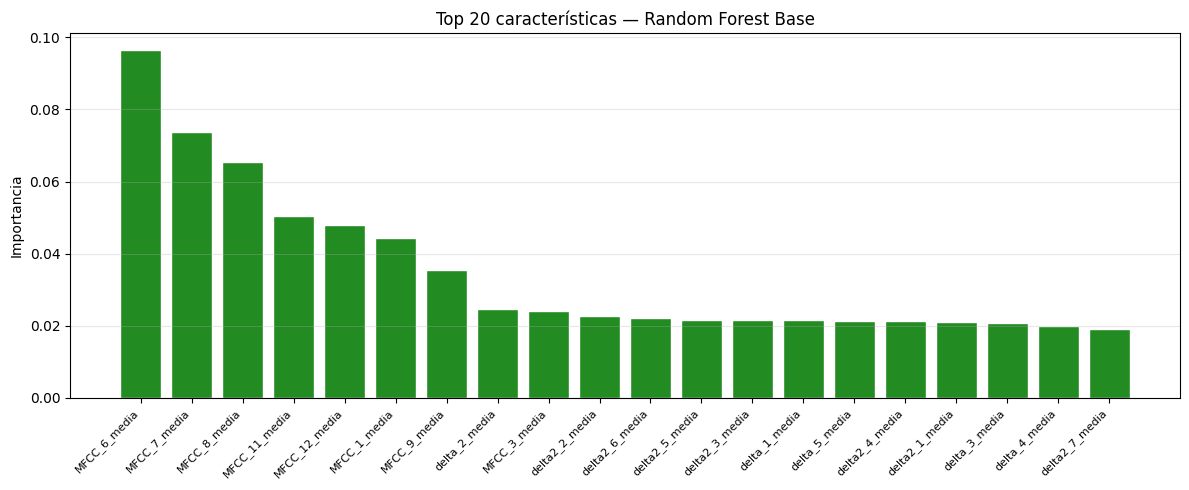

Top 5 características más importantes (RF):
  1. MFCC_6_media               importancia=0.0965
  2. MFCC_7_media               importancia=0.0737
  3. MFCC_8_media               importancia=0.0653
  4. MFCC_11_media              importancia=0.0504
  5. MFCC_12_media              importancia=0.0478


In [33]:
importancias_rf = rf_base.feature_importances_
indices_rf      = np.argsort(importancias_rf)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(20), importancias_rf[indices_rf[:20]], color='forestgreen', edgecolor='white')
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in indices_rf[:20]], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importancia')
ax.set_title('Top 20 características — Random Forest Base')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 5 características más importantes (RF):')
for i in range(5):
    print(f'  {i+1}. {feature_names[indices_rf[i]]:25s}  importancia={importancias_rf[indices_rf[i]]:.4f}')

### Interpretación — importancia de variables (RF)

Random Forest calcula la importancia de cada variable como la **reducción promedio de impureza Gini** que aporta a través de todos los árboles del bosque. A diferencia del árbol individual, esta estimación es más estable porque promedia sobre cientos de árboles entrenados con submuestras distintas.

Los coeficientes MFCC tienden a dominar porque capturan el **timbre espectral** diferenciador de cada instrumento. Los delta y delta² son relevantes para la batería, cuyo timbre cambia rápidamente (golpes percusivos cortos).

> 📝 **COMPLETAR CON TUS RESULTADOS:** Identifica las 3-5 features más importantes que arroja la gráfica. ¿Son coeficientes MFCC estáticos, deltas o delta²? ¿Tiene sentido según las características acústicas de los instrumentos?

## 2.3 GridSearchCV — ajuste de hiperparámetros

**Justificación de los valores del grid:**
- `n_estimators` [100, 200, 300]: Más árboles = mayor estabilidad, pero costo computacional creciente. Con 100 ya se obtiene una buena aproximación; 300 da el techo práctico.
- `max_depth` [None, 5, 10, 20]: `None` permite árboles completamente desarrollados (máxima varianza); 5 y 10 los regulariza moderadamente; 20 es un punto intermedio elevado.
- `criterion` ['gini', 'entropy']: Gini es más rápido computacionalmente; Entropía puede dar mejores separaciones cuando las distribuciones de clase son similares.
- `min_samples_leaf` [2, 3, 5]: Evita hojas con muy pocos ejemplos. Valores mayores generalizan mejor pero pueden perder detalle.

In [34]:
param_grid_rf2 = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 5, 10, 20],
    'criterion'       : ['gini', 'entropy'],
    'min_samples_leaf': [2, 3, 5],
}

total_rf2 = 1
for v in param_grid_rf2.values():
    total_rf2 *= len(v)
print(f'Combinaciones: {total_rf2} x 5 folds = {total_rf2*5} entrenamientos')

t0 = time.time()
gs_rf2 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf2,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
gs_rf2.fit(X_train_sc, y_train)
t_gs_rf2 = time.time() - t0

y_pred_rf_opt = gs_rf2.best_estimator_.predict(X_test_sc)
acc_rf_opt    = accuracy_score(y_test, y_pred_rf_opt)
f1_rf_opt     = f1_score(y_test, y_pred_rf_opt, average='weighted')

print(f'\nGridSearch RF completado en {t_gs_rf2:.2f}s')
print(f'  Mejor F1 en CV     : {gs_rf2.best_score_*100:.2f}%')
print(f'  Accuracy en test   : {acc_rf_opt*100:.2f}%')
print(f'  F1 en test         : {f1_rf_opt*100:.2f}%')
print(f'  Mejores parámetros : {gs_rf2.best_params_}')

Combinaciones: 72 x 5 folds = 360 entrenamientos
Fitting 5 folds for each of 72 candidates, totalling 360 fits

GridSearch RF completado en 161.79s
  Mejor F1 en CV     : 81.75%
  Accuracy en test   : 81.94%
  F1 en test         : 81.89%
  Mejores parámetros : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 300}


## 2.4 Visualización de resultados del GridSearch — RF

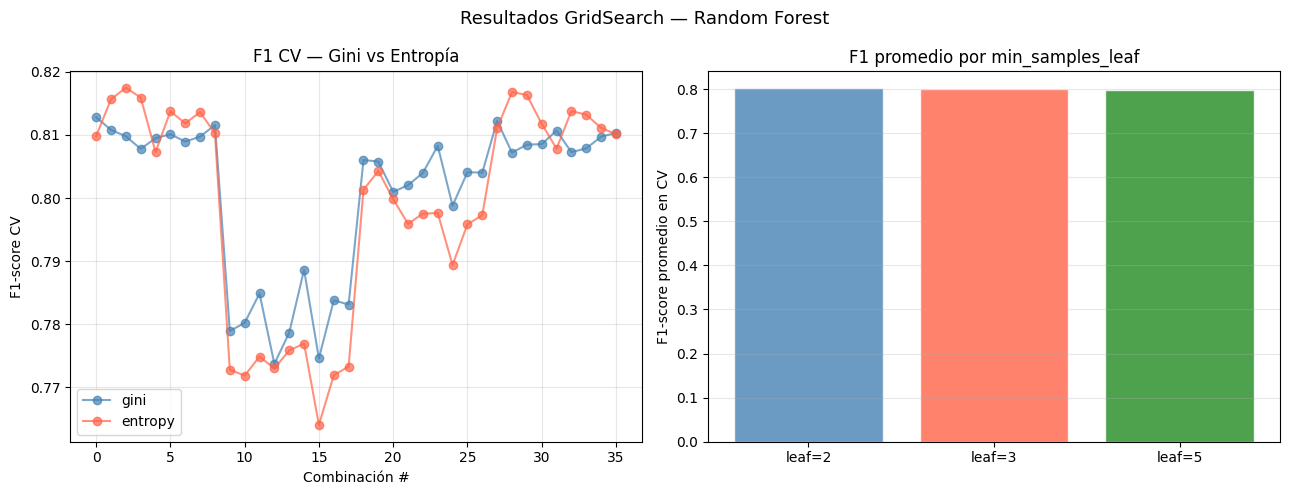

In [35]:
results_rf2 = pd.DataFrame(gs_rf2.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# F1 por criterion
for crit, color in [('gini', 'steelblue'), ('entropy', 'tomato')]:
    mask     = results_rf2['param_criterion'] == crit
    scores_c = results_rf2[mask]['mean_test_score'].values
    axes[0].plot(scores_c, 'o-', color=color, alpha=0.7, label=crit)
axes[0].set_xlabel('Combinación #')
axes[0].set_ylabel('F1-score CV')
axes[0].set_title('F1 CV — Gini vs Entropía')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 promedio por min_samples_leaf
for msl, color in zip([2, 3, 5], ['steelblue', 'tomato', 'forestgreen']):
    mask    = results_rf2['param_min_samples_leaf'] == msl
    mean_f1 = results_rf2[mask]['mean_test_score'].mean()
    axes[1].bar(f'leaf={msl}', mean_f1, color=color, alpha=0.8, edgecolor='white')
axes[1].set_ylabel('F1-score promedio en CV')
axes[1].set_title('F1 promedio por min_samples_leaf')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Resultados GridSearch — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

## 2.5 Validación cruzada estratificada 10 pliegues — RF Optimizado

RANDOM FOREST OPTIMIZADO — CV-10 Estratificado
  Accuracy  : 81.85% ± 2.81%
  Error     : 18.15% ± 2.81%
  Precisión : 81.79% ± 2.81%
  Recall    : 81.85% ± 2.81%
  F1-score  : 81.67% ± 2.85%

Reporte en test con modelo optimizado:
              precision    recall  f1-score   support

    Guitarra       0.74      0.75      0.74       240
    Acordeón       0.76      0.74      0.75       240
     Batería       0.95      0.97      0.96       240

    accuracy                           0.82       720
   macro avg       0.82      0.82      0.82       720
weighted avg       0.82      0.82      0.82       720



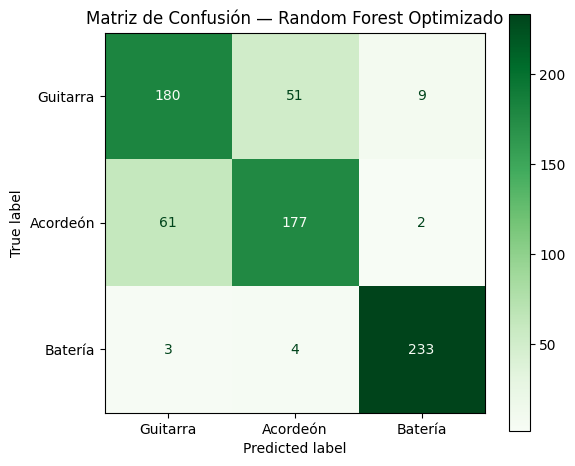

In [36]:
cv10_rf  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf_best  = gs_rf2.best_estimator_

cv_rf_acc  = cross_val_score(rf_best, X_train_sc, y_train, cv=cv10_rf, scoring='accuracy')
cv_rf_prec = cross_val_score(rf_best, X_train_sc, y_train, cv=cv10_rf, scoring='precision_weighted')
cv_rf_rec  = cross_val_score(rf_best, X_train_sc, y_train, cv=cv10_rf, scoring='recall_weighted')
cv_rf_f1   = cross_val_score(rf_best, X_train_sc, y_train, cv=cv10_rf, scoring='f1_weighted')

print('RANDOM FOREST OPTIMIZADO — CV-10 Estratificado')
print('=' * 55)
print(f'  Accuracy  : {cv_rf_acc.mean()*100:.2f}% ± {cv_rf_acc.std()*100:.2f}%')
print(f'  Error     : {(1-cv_rf_acc).mean()*100:.2f}% ± {(1-cv_rf_acc).std()*100:.2f}%')
print(f'  Precisión : {cv_rf_prec.mean()*100:.2f}% ± {cv_rf_prec.std()*100:.2f}%')
print(f'  Recall    : {cv_rf_rec.mean()*100:.2f}% ± {cv_rf_rec.std()*100:.2f}%')
print(f'  F1-score  : {cv_rf_f1.mean()*100:.2f}% ± {cv_rf_f1.std()*100:.2f}%')
print()
print('Reporte en test con modelo optimizado:')
print(classification_report(y_test, y_pred_rf_opt, target_names=NOMBRES_CLASES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_opt,
    display_labels=NOMBRES_CLASES,
    cmap='Greens', ax=ax
)
ax.set_title('Matriz de Confusión — Random Forest Optimizado')
plt.tight_layout()
plt.show()

## 2.6 Comparación RF Base vs RF Optimizado

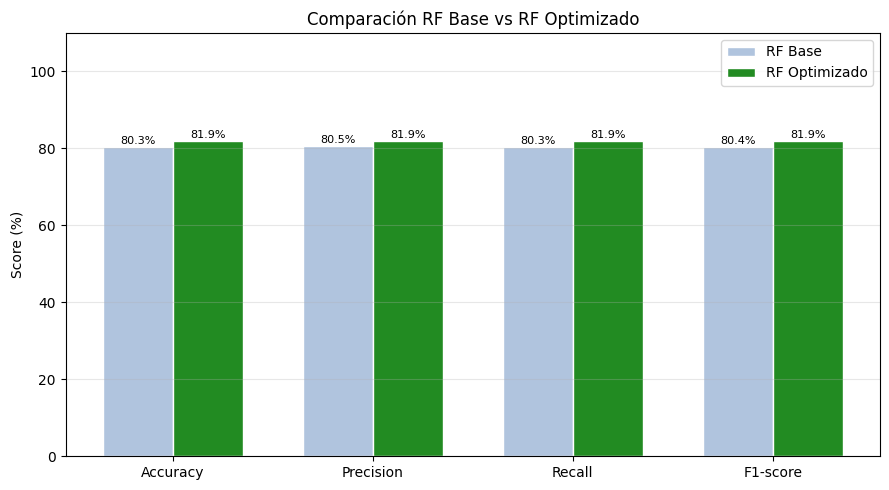

In [37]:
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-score']
vals_base_rf = [
    acc_base*100,
    precision_score(y_test, y_pred_base, average='weighted')*100,
    recall_score(y_test, y_pred_base, average='weighted')*100,
    f1_score(y_test, y_pred_base, average='weighted')*100
]
vals_opt_rf = [
    acc_rf_opt*100,
    precision_score(y_test, y_pred_rf_opt, average='weighted')*100,
    recall_score(y_test, y_pred_rf_opt, average='weighted')*100,
    f1_score(y_test, y_pred_rf_opt, average='weighted')*100
]

x = np.arange(4)
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, vals_base_rf, w, label='RF Base',       color='lightsteelblue', edgecolor='white')
b2 = ax.bar(x + w/2, vals_opt_rf,  w, label='RF Optimizado', color='forestgreen',    edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.set_title('Comparación RF Base vs RF Optimizado')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### Interpretación — RF Base vs Optimizado

El GridSearchCV explora 72 combinaciones de hiperparámetros para encontrar la configuración que maximiza el F1-score en validación cruzada.

- **Gini vs Entropía:** Gini tiende a ser más rápido computacionalmente y funciona bien en la mayoría de casos. La entropía puede capturar mejor divisiones en clases con distribuciones similares (como guitarra y acordeón que comparten rangos espectrales cercanos).
- **`min_samples_leaf`:** Controlar el tamaño mínimo de hoja evita que el bosque cree divisiones sobre ruido. Un valor más alto generaliza mejor pero puede perder patrones finos.
- **`max_depth`:** Restringir la profundidad reduce la varianza del bosque. `None` deja que cada árbol crezca completamente, lo que puede llevar a sobreajuste aunque el bagging lo mitiga.

Si el modelo base ya tenía buen desempeño, la mejora del optimizado puede ser modesta — esto es normal cuando las features MFCC son altamente discriminantes para los tres instrumentos.

> 📝 **COMPLETAR CON TUS RESULTADOS:** ¿Hubo mejora significativa (>2%) al optimizar? ¿Qué combinación de parámetros resultó ser la mejor según `gs_rf2.best_params_`? ¿Ganó Gini o Entropía? ¿Qué valor de `min_samples_leaf` resultó óptimo?

---
# ⚡ Modelo 3: XGBoost

XGBoost (*eXtreme Gradient Boosting*) construye árboles de manera **secuencial**: cada árbol nuevo corrige los errores del anterior usando el gradiente de la función de pérdida. A diferencia del Random Forest (que usa bagging en paralelo), XGBoost aplica **boosting**, lo que lo hace más poderoso pero también más sensible al ajuste de hiperparámetros.

| Parámetro | Descripción |
|-----------|-------------|
| `n_estimators` | Número de rondas de boosting (árboles) |
| `max_depth` | Profundidad máxima de cada árbol |
| `learning_rate` (eta) | Cuánto aporta cada árbol nuevo al ensemble |
| `colsample_bytree` | Fracción de features usada por árbol |
| `gamma` | Ganancia mínima para realizar un split (poda) |
| `reg_lambda` | Regularización L2 sobre pesos de hojas |

## 3.1 Modelo base XGBoost

Se configura el modelo base con parámetros conservadores y representativos: 100 árboles, profundidad 6 y tasa de aprendizaje 0.1. Estos son valores estándar usados como punto de partida antes del ajuste fino.

XGBOOST BASE  (tiempo: 1.45s)
  Exactitud           : 81.67%
  Error clasificación : 18.33%
  Precisión (weighted): 81.49%
  Recall (weighted)   : 81.67%
  F1-score (weighted) : 81.57%

              precision    recall  f1-score   support

    Guitarra       0.74      0.72      0.73       240
    Acordeón       0.74      0.74      0.74       240
     Batería       0.96      0.98      0.97       240

    accuracy                           0.82       720
   macro avg       0.81      0.82      0.82       720
weighted avg       0.81      0.82      0.82       720



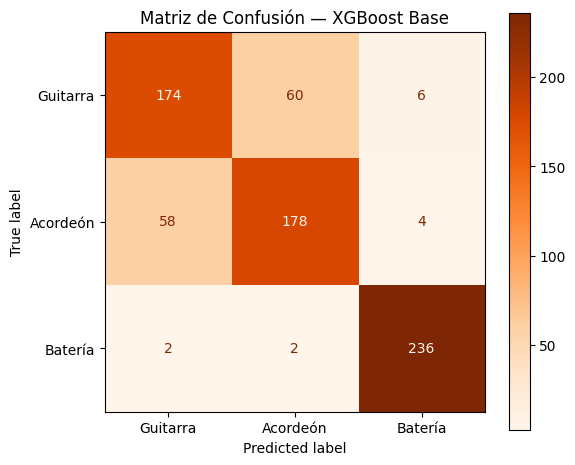

In [38]:
xgb_base = XGBClassifier(
    booster='gbtree',
    objective='multi:softmax',
    num_class=3,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    colsample_bytree=0.8,
    gamma=0,
    reg_lambda=1,
    random_state=42,
    eval_metric='merror',
    verbosity=0
)

t0 = time.time()
xgb_base.fit(X_train_sc, y_train)
t_xgb_base = time.time() - t0

y_pred_xgb = xgb_base.predict(X_test_sc)

acc_xgb  = accuracy_score(y_test, y_pred_xgb)
err_xgb  = 1 - acc_xgb
prec_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
rec_xgb  = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb   = f1_score(y_test, y_pred_xgb, average='weighted')

print(f'XGBOOST BASE  (tiempo: {t_xgb_base:.2f}s)')
print('=' * 50)
print(f'  Exactitud           : {acc_xgb*100:.2f}%')
print(f'  Error clasificación : {err_xgb*100:.2f}%')
print(f'  Precisión (weighted): {prec_xgb*100:.2f}%')
print(f'  Recall (weighted)   : {rec_xgb*100:.2f}%')
print(f'  F1-score (weighted) : {f1_xgb*100:.2f}%')
print()
print(classification_report(y_test, y_pred_xgb, target_names=NOMBRES_CLASES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=NOMBRES_CLASES,
    cmap='Oranges', ax=ax
)
ax.set_title('Matriz de Confusión — XGBoost Base')
plt.tight_layout()
plt.show()

## 3.2 Importancia de características — XGBoost

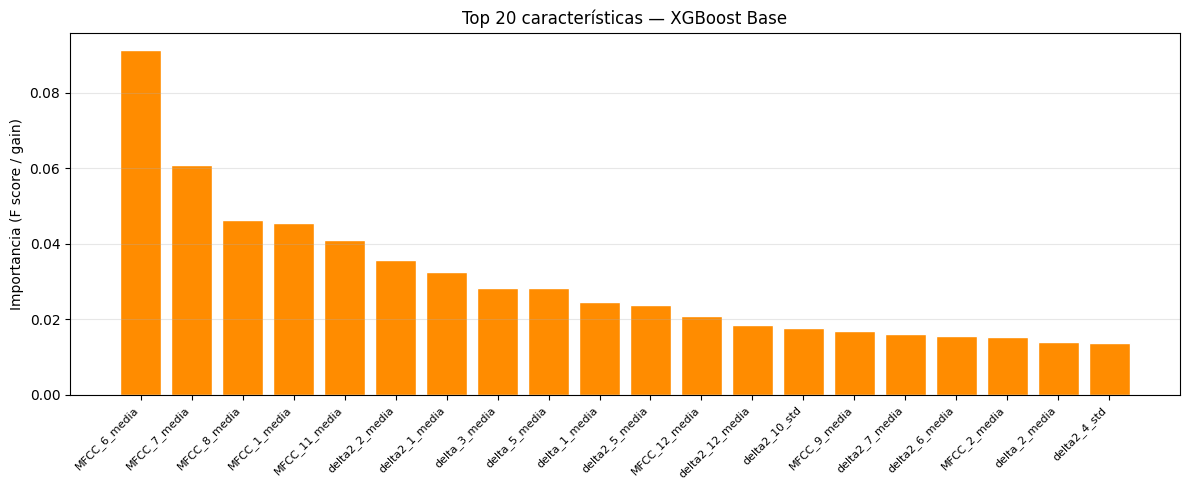

Top 5 características más importantes (XGBoost):
  1. MFCC_6_media               importancia=0.0913
  2. MFCC_7_media               importancia=0.0608
  3. MFCC_8_media               importancia=0.0462
  4. MFCC_1_media               importancia=0.0454
  5. MFCC_11_media              importancia=0.0410


In [39]:
importancias_xgb = xgb_base.feature_importances_
indices_xgb      = np.argsort(importancias_xgb)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(20), importancias_xgb[indices_xgb[:20]], color='darkorange', edgecolor='white')
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in indices_xgb[:20]], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importancia (F score / gain)')
ax.set_title('Top 20 características — XGBoost Base')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 5 características más importantes (XGBoost):')
for i in range(5):
    print(f'  {i+1}. {feature_names[indices_xgb[i]]:25s}  importancia={importancias_xgb[indices_xgb[i]]:.4f}')

### Interpretación — importancia en XGBoost

XGBoost mide la importancia mediante el **gain** (reducción de pérdida promedio por split), que es más informativo que la frecuencia de uso. Si las características más importantes en XGBoost difieren de las del Random Forest, significa que el boosting secuencial explota el espacio de features de forma distinta al bagging: cada árbol nuevo en XGBoost se enfoca en los errores que cometen los árboles anteriores, lo que puede poner en evidencia interacciones no lineales entre coeficientes MFCC que el bosque aleatorio no captura de la misma forma.

> 📝 **COMPLETAR CON TUS RESULTADOS:** Compara las top features de XGBoost con las del Random Forest. ¿Coinciden las más importantes? ¿XGBoost le da más relevancia a los deltas que RF? Eso podría indicar que captura mejor la dinámica temporal de los instrumentos.

## 3.3 GridSearchCV — XGBoost (con todos los parámetros requeridos)

**Justificación de los valores del grid:**
- `n_estimators` [200, 400, 600]: Más rondas de boosting permiten corregir más errores residuales. Valores altos son útiles especialmente con tasas de aprendizaje bajas.
- `max_depth` [4, 6, 8]: Árboles más profundos capturan interacciones complejas entre features MFCC, pero aumentan el riesgo de sobreajuste.
- `learning_rate` [0.01, 0.05, 0.1]: Tasas bajas requieren más árboles pero suelen generalizar mejor. La combinación `lr=0.01 + n_est=600` típicamente produce resultados sólidos.
- `colsample_bytree` [0.8, 1.0]: Usar solo el 80% de las features por árbol introduce aleatoriedad similar al RF, reduciendo la correlación entre árboles y el overfitting.
- `gamma` [0, 1]: Controla cuánta ganancia mínima se exige para realizar un split. `gamma=0` permite cualquier split; `gamma=1` poda divisiones con poco beneficio.
- `reg_lambda` [1, 5]: Regularización L2. Un valor mayor penaliza pesos grandes en las hojas, ayudando cuando hay features correlacionadas (MFCC consecutivos).

> ⚠️ Este grid genera 3×3×3×2×2×2 = **216 combinaciones** × 5 folds = **1080 entrenamientos**. Con `n_jobs=-1` usará todos los núcleos disponibles y puede tardar varios minutos.

In [40]:
param_grid_xgb = {
    'n_estimators'    : [200, 400, 600],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'colsample_bytree': [0.8, 1.0],
    'gamma'           : [0, 1],
    'reg_lambda'      : [1, 5],
}

total_xgb = 1
for v in param_grid_xgb.values():
    total_xgb *= len(v)
print(f'Combinaciones: {total_xgb} x 5 folds = {total_xgb*5} entrenamientos')
print('Ejecutando (puede tardar varios minutos)...')

t0 = time.time()
gs_xgb = GridSearchCV(
    XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        random_state=42,
        eval_metric='merror',
        verbosity=0
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
gs_xgb.fit(X_train_sc, y_train)
t_gs_xgb = time.time() - t0

y_pred_xgb_opt = gs_xgb.best_estimator_.predict(X_test_sc)
acc_xgb_opt    = accuracy_score(y_test, y_pred_xgb_opt)
f1_xgb_opt     = f1_score(y_test, y_pred_xgb_opt, average='weighted')

print(f'\nGridSearch XGB completado en {t_gs_xgb:.2f}s')
print(f'  Mejor F1 en CV     : {gs_xgb.best_score_*100:.2f}%')
print(f'  Accuracy en test   : {acc_xgb_opt*100:.2f}%')
print(f'  F1 en test         : {f1_xgb_opt*100:.2f}%')
print(f'  Mejores parámetros : {gs_xgb.best_params_}')

Combinaciones: 216 x 5 folds = 1080 entrenamientos
Ejecutando (puede tardar varios minutos)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

GridSearch XGB completado en 1448.82s
  Mejor F1 en CV     : 84.59%
  Accuracy en test   : 82.64%
  F1 en test         : 82.54%
  Mejores parámetros : {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'reg_lambda': 5}


## 3.4 Visualización de resultados del GridSearch — XGBoost

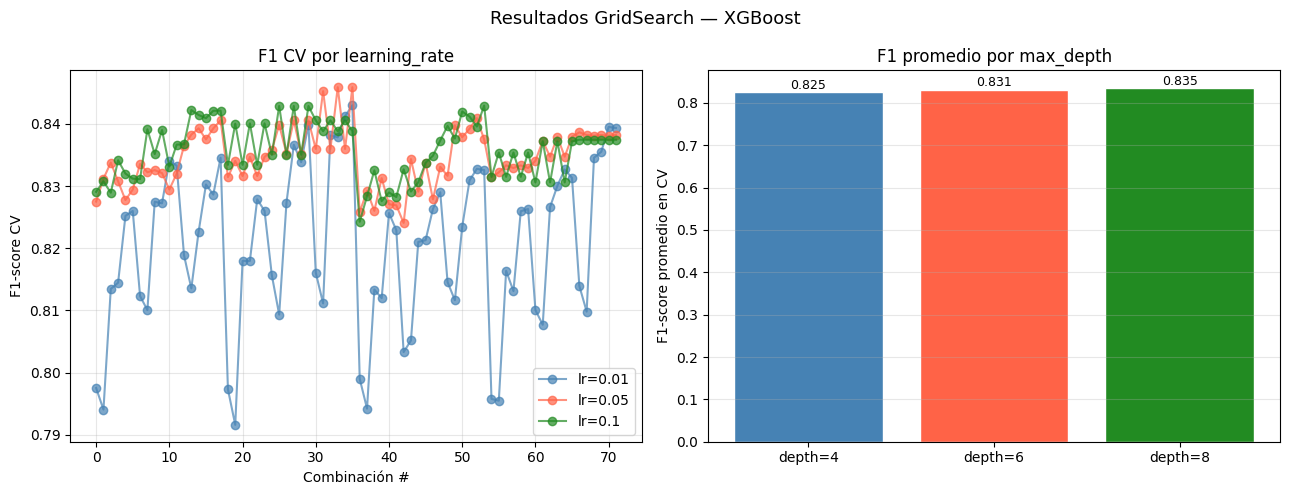

In [41]:
results_xgb = pd.DataFrame(gs_xgb.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# F1 por learning_rate
for lr, color in zip([0.01, 0.05, 0.1], ['steelblue', 'tomato', 'forestgreen']):
    mask = results_xgb['param_learning_rate'] == lr
    axes[0].plot(results_xgb[mask]['mean_test_score'].values, 'o-',
                 color=color, alpha=0.7, label=f'lr={lr}')
axes[0].set_xlabel('Combinación #')
axes[0].set_ylabel('F1-score CV')
axes[0].set_title('F1 CV por learning_rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 promedio por max_depth
f1_por_depth = [results_xgb[results_xgb['param_max_depth'] == d]['mean_test_score'].mean()
                for d in [4, 6, 8]]
bars_d = axes[1].bar(['depth=4', 'depth=6', 'depth=8'], f1_por_depth,
                      color=['steelblue', 'tomato', 'forestgreen'], edgecolor='white')
axes[1].set_ylabel('F1-score promedio en CV')
axes[1].set_title('F1 promedio por max_depth')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_por_depth):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Resultados GridSearch — XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

## 3.5 Validación cruzada estratificada 10 pliegues — XGBoost optimizado

XGBOOST OPTIMIZADO — CV-10 Estratificado
  Accuracy  : 83.69% ± 1.62%
  Error     : 16.31% ± 1.62%
  Precisión : 83.60% ± 1.69%
  Recall    : 83.69% ± 1.62%
  F1-score  : 83.54% ± 1.62%

Reporte en test con XGBoost optimizado:
              precision    recall  f1-score   support

    Guitarra       0.75      0.76      0.76       240
    Acordeón       0.77      0.74      0.76       240
     Batería       0.95      0.98      0.97       240

    accuracy                           0.83       720
   macro avg       0.82      0.83      0.83       720
weighted avg       0.82      0.83      0.83       720



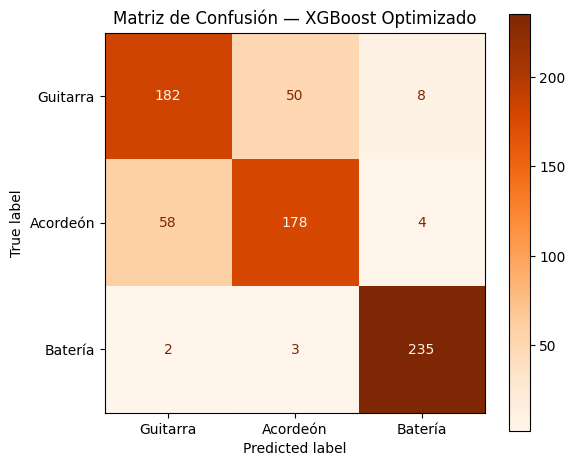

In [42]:
cv10_xgb = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
xgb_best = gs_xgb.best_estimator_

cv_xgb_acc  = cross_val_score(xgb_best, X_train_sc, y_train, cv=cv10_xgb, scoring='accuracy')
cv_xgb_prec = cross_val_score(xgb_best, X_train_sc, y_train, cv=cv10_xgb, scoring='precision_weighted')
cv_xgb_rec  = cross_val_score(xgb_best, X_train_sc, y_train, cv=cv10_xgb, scoring='recall_weighted')
cv_xgb_f1   = cross_val_score(xgb_best, X_train_sc, y_train, cv=cv10_xgb, scoring='f1_weighted')

print('XGBOOST OPTIMIZADO — CV-10 Estratificado')
print('=' * 55)
print(f'  Accuracy  : {cv_xgb_acc.mean()*100:.2f}% ± {cv_xgb_acc.std()*100:.2f}%')
print(f'  Error     : {(1-cv_xgb_acc).mean()*100:.2f}% ± {(1-cv_xgb_acc).std()*100:.2f}%')
print(f'  Precisión : {cv_xgb_prec.mean()*100:.2f}% ± {cv_xgb_prec.std()*100:.2f}%')
print(f'  Recall    : {cv_xgb_rec.mean()*100:.2f}% ± {cv_xgb_rec.std()*100:.2f}%')
print(f'  F1-score  : {cv_xgb_f1.mean()*100:.2f}% ± {cv_xgb_f1.std()*100:.2f}%')
print()
print('Reporte en test con XGBoost optimizado:')
print(classification_report(y_test, y_pred_xgb_opt, target_names=NOMBRES_CLASES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_opt,
    display_labels=NOMBRES_CLASES,
    cmap='Oranges', ax=ax
)
ax.set_title('Matriz de Confusión — XGBoost Optimizado')
plt.tight_layout()
plt.show()

## 3.6 Comparación XGBoost Base vs Optimizado

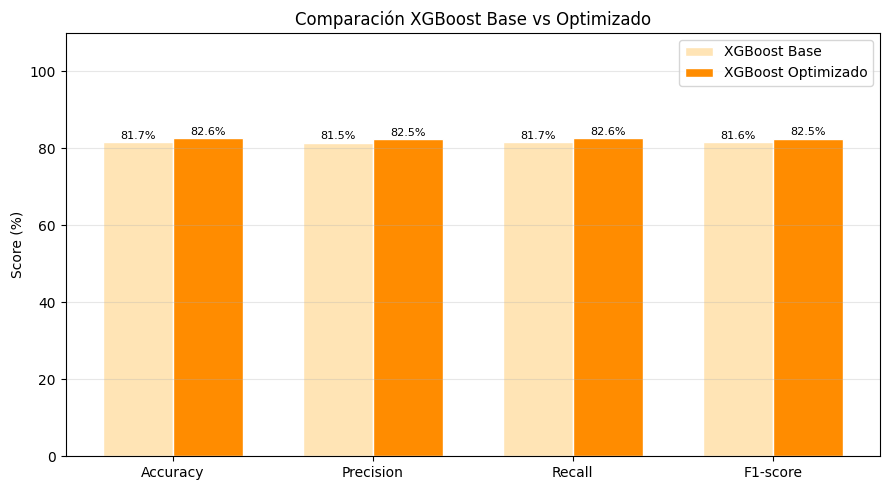

In [43]:
vals_xgb_base = [
    acc_xgb*100,
    precision_score(y_test, y_pred_xgb, average='weighted')*100,
    recall_score(y_test, y_pred_xgb, average='weighted')*100,
    f1_score(y_test, y_pred_xgb, average='weighted')*100
]
vals_xgb_opt = [
    acc_xgb_opt*100,
    precision_score(y_test, y_pred_xgb_opt, average='weighted')*100,
    recall_score(y_test, y_pred_xgb_opt, average='weighted')*100,
    f1_score(y_test, y_pred_xgb_opt, average='weighted')*100
]

x = np.arange(4)
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, vals_xgb_base, w, label='XGBoost Base',       color='moccasin',   edgecolor='white')
b2 = ax.bar(x + w/2, vals_xgb_opt,  w, label='XGBoost Optimizado', color='darkorange',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-score'])
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.set_title('Comparación XGBoost Base vs Optimizado')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### Interpretación — XGBoost Base vs Optimizado

XGBoost es especialmente sensible a la interacción entre `learning_rate` y `n_estimators`: una tasa alta con pocos árboles puede subajustar, mientras que una tasa baja requiere muchos más árboles para converger pero suele generalizar mejor.

- **`gamma`** actúa como regularizador de árbol: un valor mayor exige que cada split aporte una ganancia mínima, produciendo árboles más simples y con menos overfitting.
- **`reg_lambda`** penaliza pesos grandes en las hojas (regularización L2), útil cuando hay features correlacionadas como los coeficientes MFCC consecutivos.
- **`colsample_bytree < 1.0`** introduce aleatoriedad (similar al RF), reduciendo la correlación entre árboles del ensemble.

> 📝 **COMPLETAR CON TUS RESULTADOS:** Indica los mejores parámetros encontrados. ¿Qué `learning_rate` ganó? ¿Se favoreció la regularización alta (gamma>0, lambda>1) o baja? ¿La optimización mejoró notablemente sobre el modelo base o el base ya era suficientemente bueno?

---
# 📊 Comparación Final — Los 3 Modelos

Modelo                      Accuracy   F1-score
-----------------------------------------------
Árbol (opt)                   75.56%     75.57%
RF (base)                     80.28%     80.36%
RF (opt)                      81.94%     81.89%
XGBoost (base)                81.67%     81.57%
XGBoost (opt)                 82.64%     82.54%


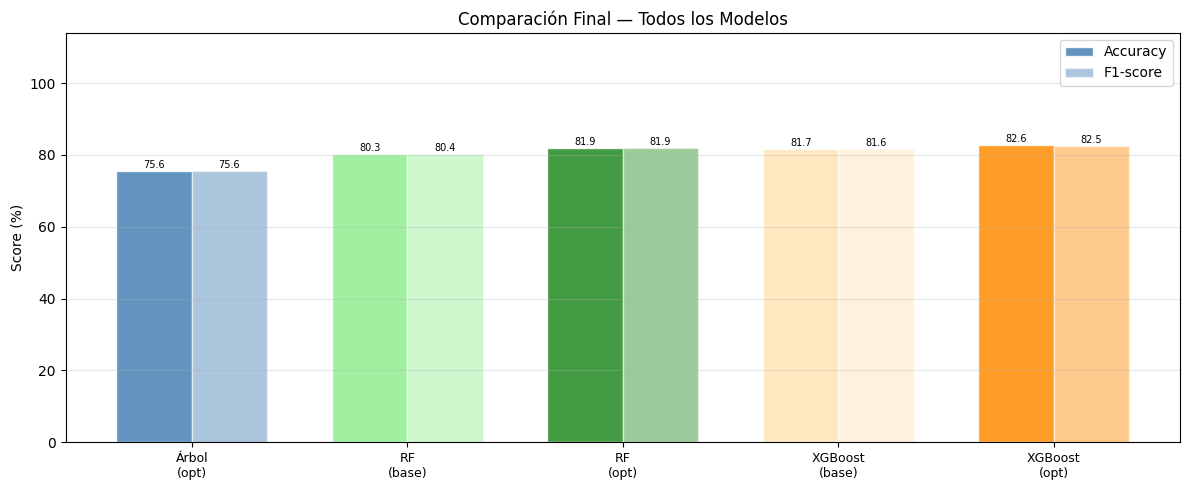

In [44]:
modelos_nombres = [
    'Árbol\n(opt)',
    'RF\n(base)',
    'RF\n(opt)',
    'XGBoost\n(base)',
    'XGBoost\n(opt)'
]

accs_finales = [
    acc_dt_opt*100,
    acc_base*100,
    acc_rf_opt*100,
    acc_xgb*100,
    acc_xgb_opt*100
]
f1s_finales = [
    f1_score(y_test, y_pred_dt_opt, average='weighted')*100,
    f1_score(y_test, y_pred_base, average='weighted')*100,
    f1_rf_opt*100,
    f1_xgb*100,
    f1_xgb_opt*100
]

nombres_flat = ['Árbol (opt)', 'RF (base)', 'RF (opt)', 'XGBoost (base)', 'XGBoost (opt)']
print(f'{"Modelo":<25} {"Accuracy":>10} {"F1-score":>10}')
print('-' * 47)
for nombre, acc, f1 in zip(nombres_flat, accs_finales, f1s_finales):
    print(f'{nombre:<25} {acc:>9.2f}% {f1:>9.2f}%')

x = np.arange(5)
w = 0.35
colores_f = ['steelblue', 'lightgreen', 'forestgreen', 'moccasin', 'darkorange']
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, accs_finales, w, label='Accuracy', color=colores_f, edgecolor='white', alpha=0.85)
b2 = ax.bar(x + w/2, f1s_finales,  w, label='F1-score', color=colores_f, edgecolor='white', alpha=0.45)
ax.set_xticks(x)
ax.set_xticklabels(modelos_nombres, fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 114)
ax.set_title('Comparación Final — Todos los Modelos')
ax.legend(['Accuracy', 'F1-score'])
ax.grid(axis='y', alpha=0.3)
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

### Conclusiones generales

**Árbol de Decisión:** Es el modelo más simple e interpretable. Permite visualizar las reglas de decisión y encontrar la profundidad óptima que balancea sesgo y varianza mediante la gráfica de error. Su desempeño es generalmente menor que los ensambles debido a la alta varianza del árbol individual.

**Random Forest:** Mejora significativamente sobre el árbol individual combinando múltiples árboles con submuestras aleatorias de datos y características (bagging + feature randomness). Es robusto al sobreajuste y proporciona una estimación estable de la importancia de variables. El GridSearchCV permitió afinar la función de impureza y el tamaño mínimo de hoja.

**XGBoost:** Generalmente el modelo más potente gracias al boosting secuencial y la regularización L1/L2 incorporada. Es más sensible al ajuste de hiperparámetros, pero muy efectivo cuando hay interacciones complejas entre features como las relaciones entre coeficientes MFCC de distintos registros temporales.

> 📝 **COMPLETAR CON TUS RESULTADOS:** Con los números reales de tu ejecución, completa este párrafo: *"El modelo con mejor desempeño fue [MODELO] con un accuracy de [X]% y F1-score de [Y]%. El Árbol de Decisión quedó [Z]% por debajo del mejor modelo, lo que confirma el beneficio de los ensambles. La optimización de hiperparámetros [sí/no] produjo mejoras significativas en [RF/XGBoost], con una ganancia de [N]% en F1-score."*